In [1]:
file = "002_yield"

In [2]:
import polars as pl

df = pl.read_excel("combined.xlsx")

In [3]:
df

arene,alkene,PG,backbone,pyridone,alpha1,beta1,all1,alpha2,beta2,all2,alpha_av,beta_av,all_av,alpha_dev,beta_dev,all_dev
i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0,0,0,3.659641,49.211079,52.870719,4.569624,53.565635,58.135259,4.114632,51.388357,55.502989,-0.909983,-4.354556,-5.264539
0,0,0,0,1,3.12128,64.922922,68.044201,3.705099,62.760926,66.466025,3.413189,63.841924,67.255113,-0.583819,2.161996,1.578176
0,0,0,0,2,2.364572,59.87745,62.242023,2.590455,58.292872,60.883327,2.477514,59.085161,61.562675,-0.225882,1.584578,1.358696
0,0,0,0,3,2.446972,52.129263,54.576235,2.916464,53.990178,56.906642,2.681718,53.059721,55.741439,-0.469492,-1.860915,-2.330407
0,0,0,0,4,2.803536,48.334072,51.137609,3.830003,59.501541,63.331543,3.31677,53.917807,57.234576,-1.026466,-11.167468,-12.193935
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0,20,8,3.437961,20.51143,23.949391,2.866987,17.944757,20.811744,3.152474,19.228094,22.380568,0.570974,2.566673,3.137647
0,0,0,20,9,4.480165,26.729398,31.209563,3.391717,22.462407,25.854125,3.935941,24.595903,28.531844,1.088448,4.266991,5.355439
0,0,0,20,10,3.692312,23.079329,26.771641,2.970595,19.041197,22.011791,3.331453,21.060263,24.391716,0.721717,4.038132,4.75985


In [4]:
columns_header = [
    "pyridone",
    "backbone",
]
columns_feat = [
    "beta1",
    "beta2",
    "beta_av",
    "alpha1",
    "alpha2",
    "alpha_av",
]

In [5]:
df = (
    df
    .select(columns_header + columns_feat)
    .sort(columns_header)
    .rename({"backbone": "MPAA"})
    .with_columns(pl.col("MPAA").replace([19, 20], [6, 7]))
    .with_columns(pl.col(columns_feat).map_elements(lambda x: f"{x:.1f}", return_dtype=pl.String))
)

In [6]:
df

pyridone,MPAA,beta1,beta2,beta_av,alpha1,alpha2,alpha_av
i64,i64,str,str,str,str,str,str
0,0,"""49.2""","""53.6""","""51.4""","""3.7""","""4.6""","""4.1"""
0,1,"""51.6""","""51.5""","""51.5""","""4.3""","""3.7""","""4.0"""
0,2,"""47.1""","""48.6""","""47.8""","""3.4""","""3.5""","""3.4"""
0,3,"""45.0""","""50.7""","""47.8""","""3.4""","""3.9""","""3.6"""
0,4,"""46.6""","""41.4""","""44.0""","""3.6""","""3.1""","""3.3"""
…,…,…,…,…,…,…,…
12,3,"""40.7""","""51.5""","""46.1""","""3.0""","""4.1""","""3.6"""
12,4,"""52.7""","""46.8""","""49.7""","""4.0""","""3.5""","""3.7"""
12,5,"""43.7""","""54.3""","""49.0""","""1.1""","""1.3""","""1.2"""


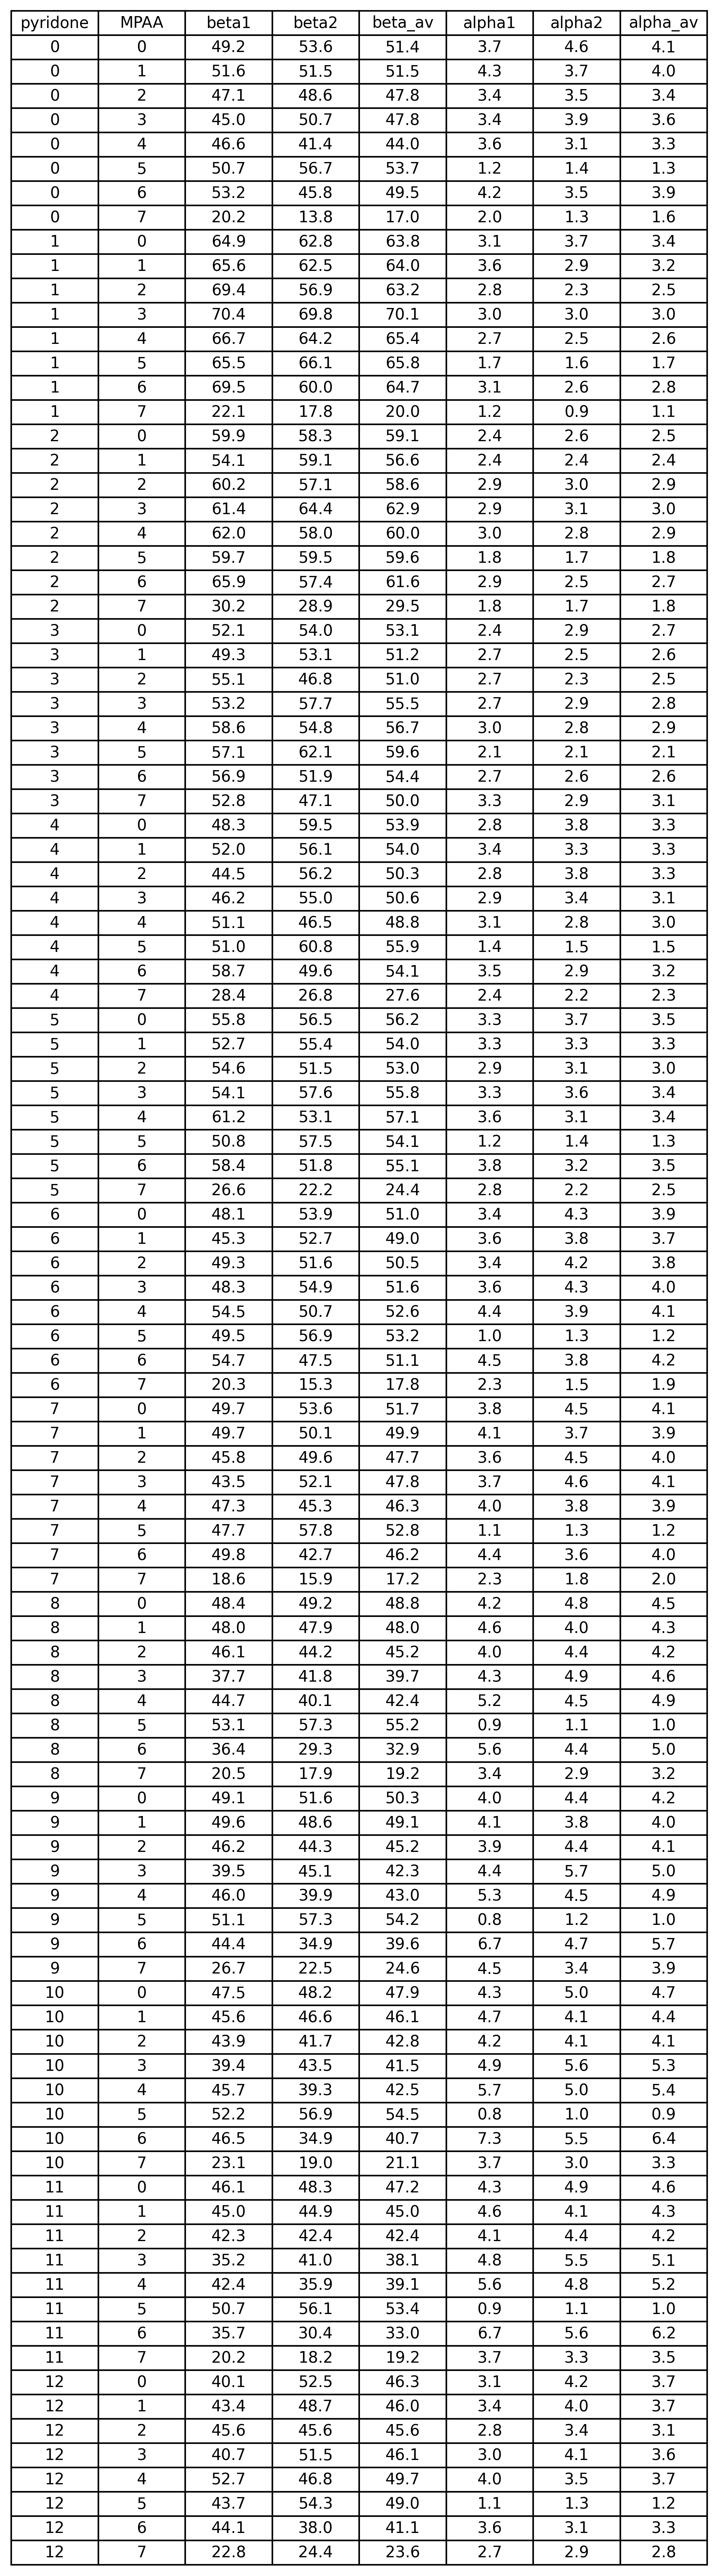

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 1), dpi=300)

table = ax.table(
    cellText=df.to_numpy(),
    colLabels=df.columns,
    loc="center",
    cellLoc="center",
)
table.scale(1.0, 1.3)

ax.axis("off")

plt.savefig(
    f"{file}_table.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [8]:
import numpy as np

separation = {
    "0-4": np.arange(0, 5),
    "5-9": np.arange(5, 10),
    "10-12": np.arange(10, 13),
}

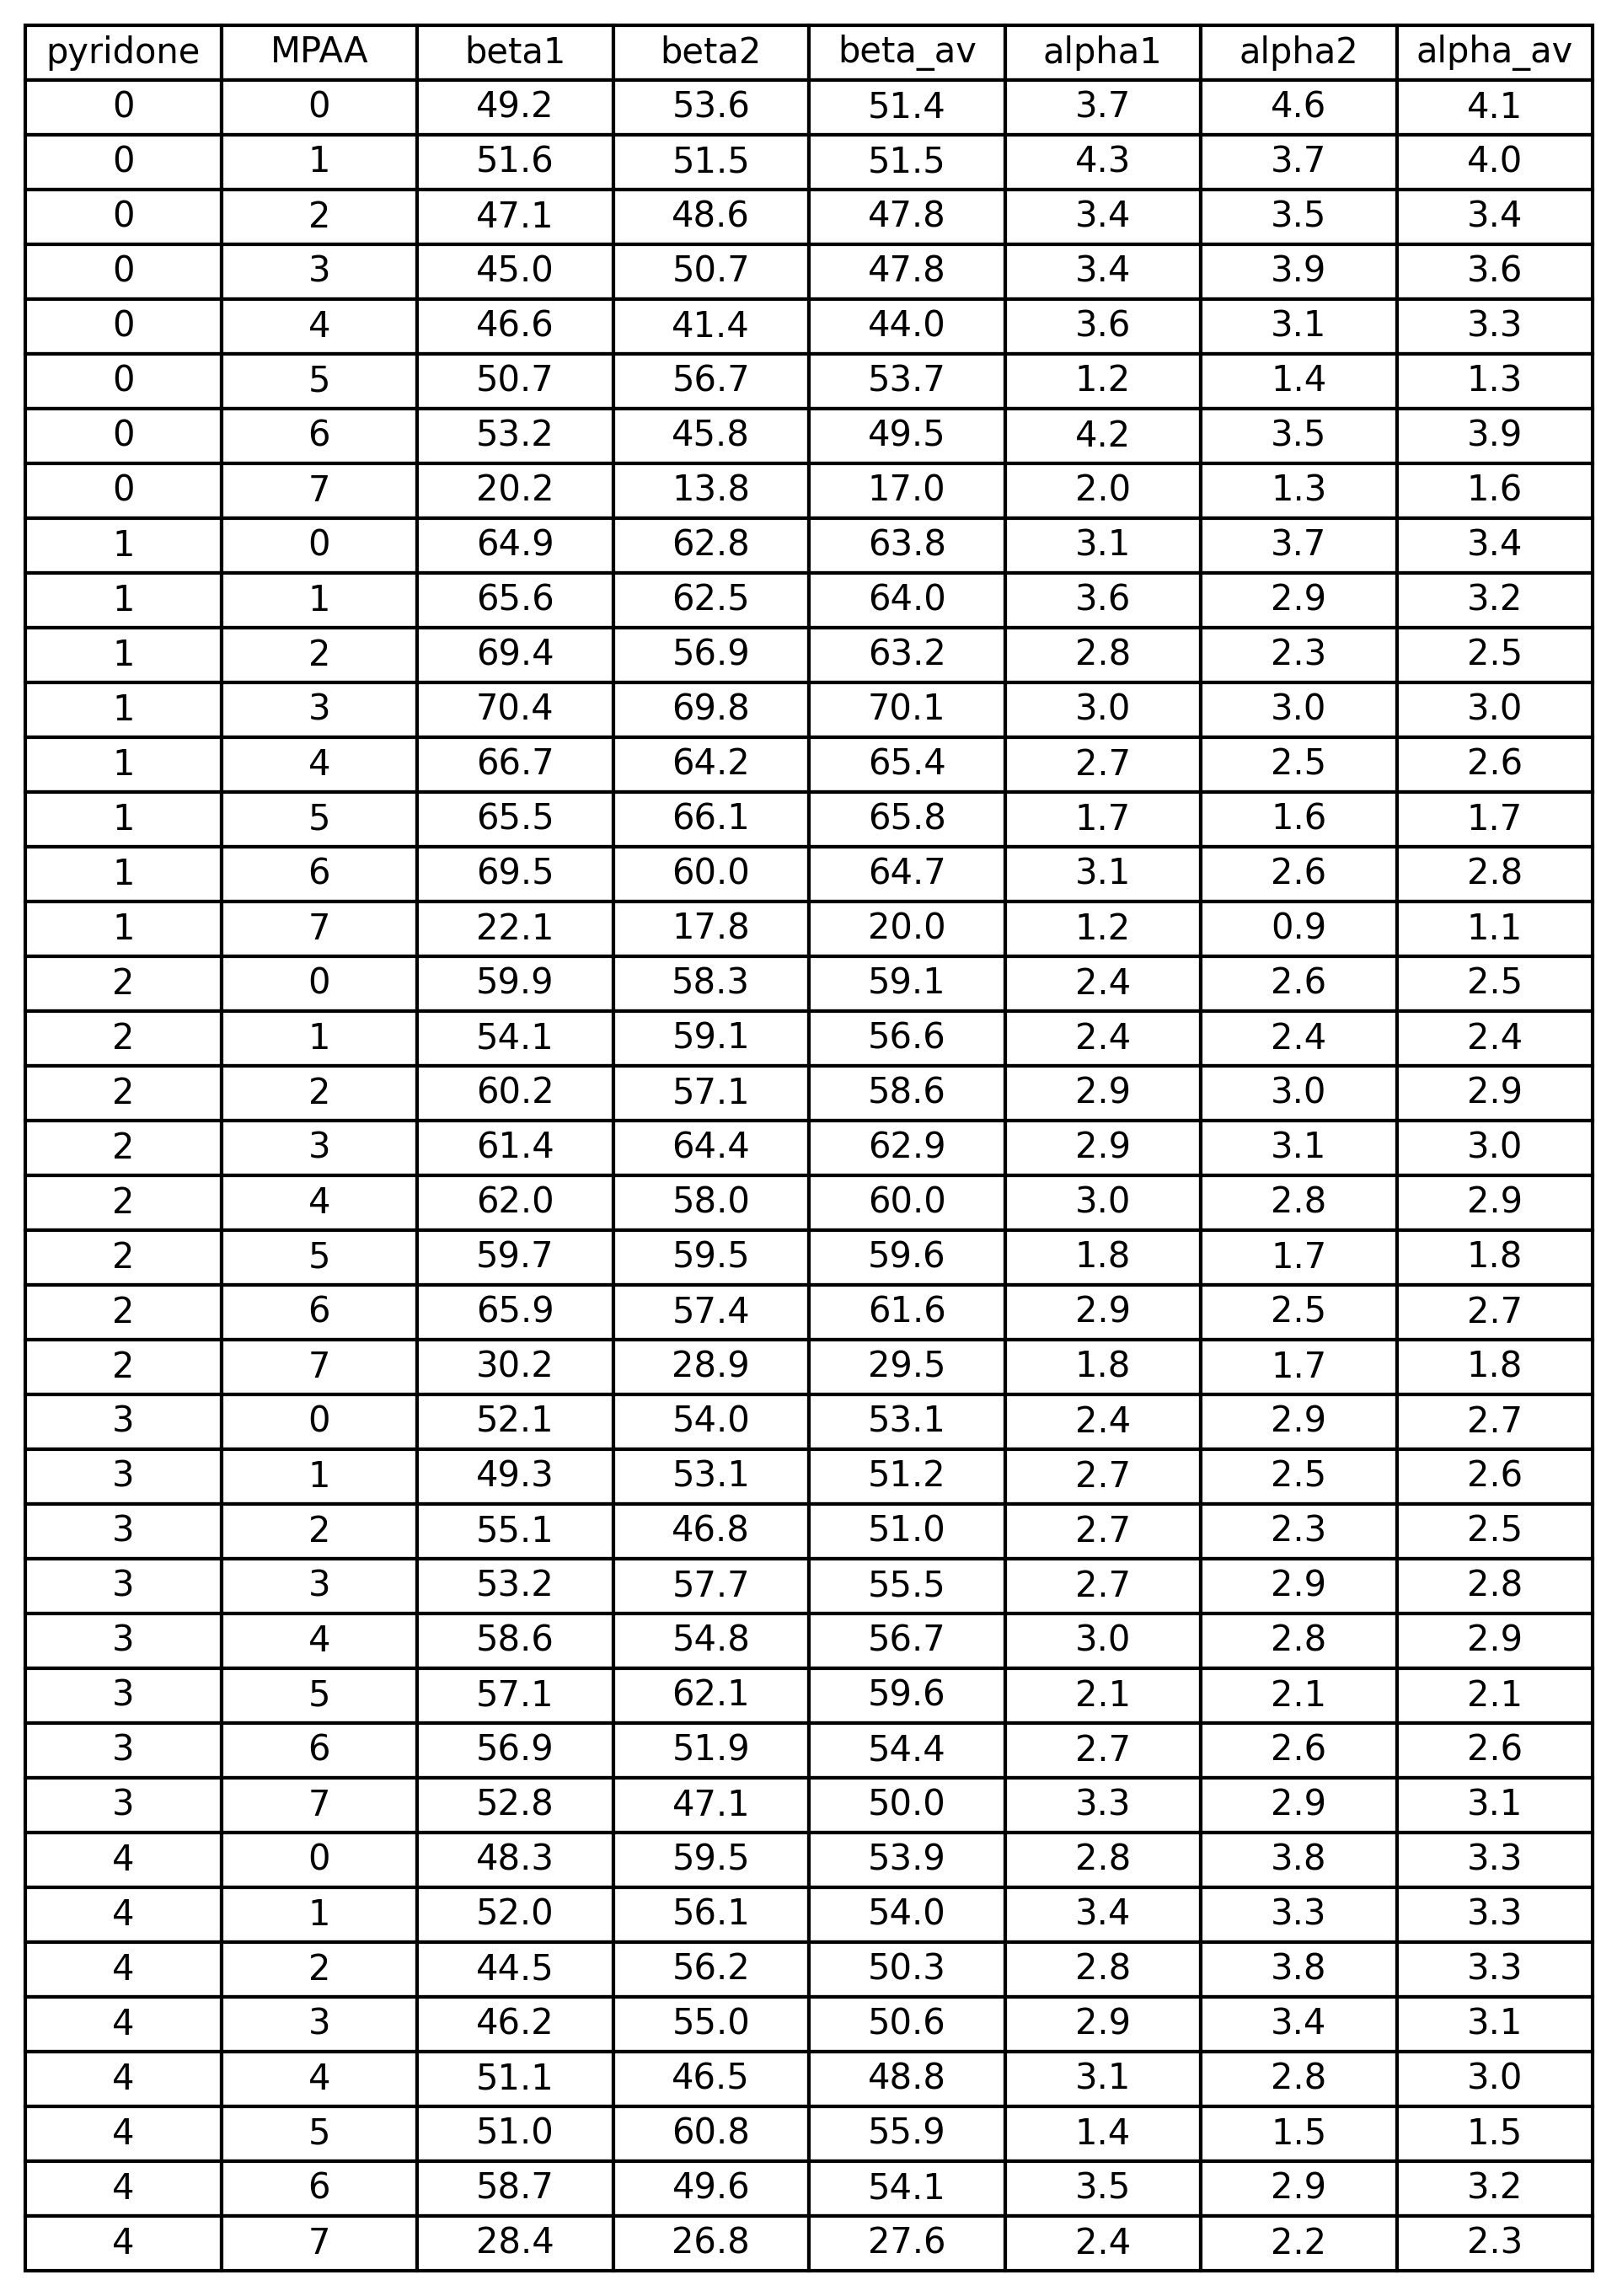

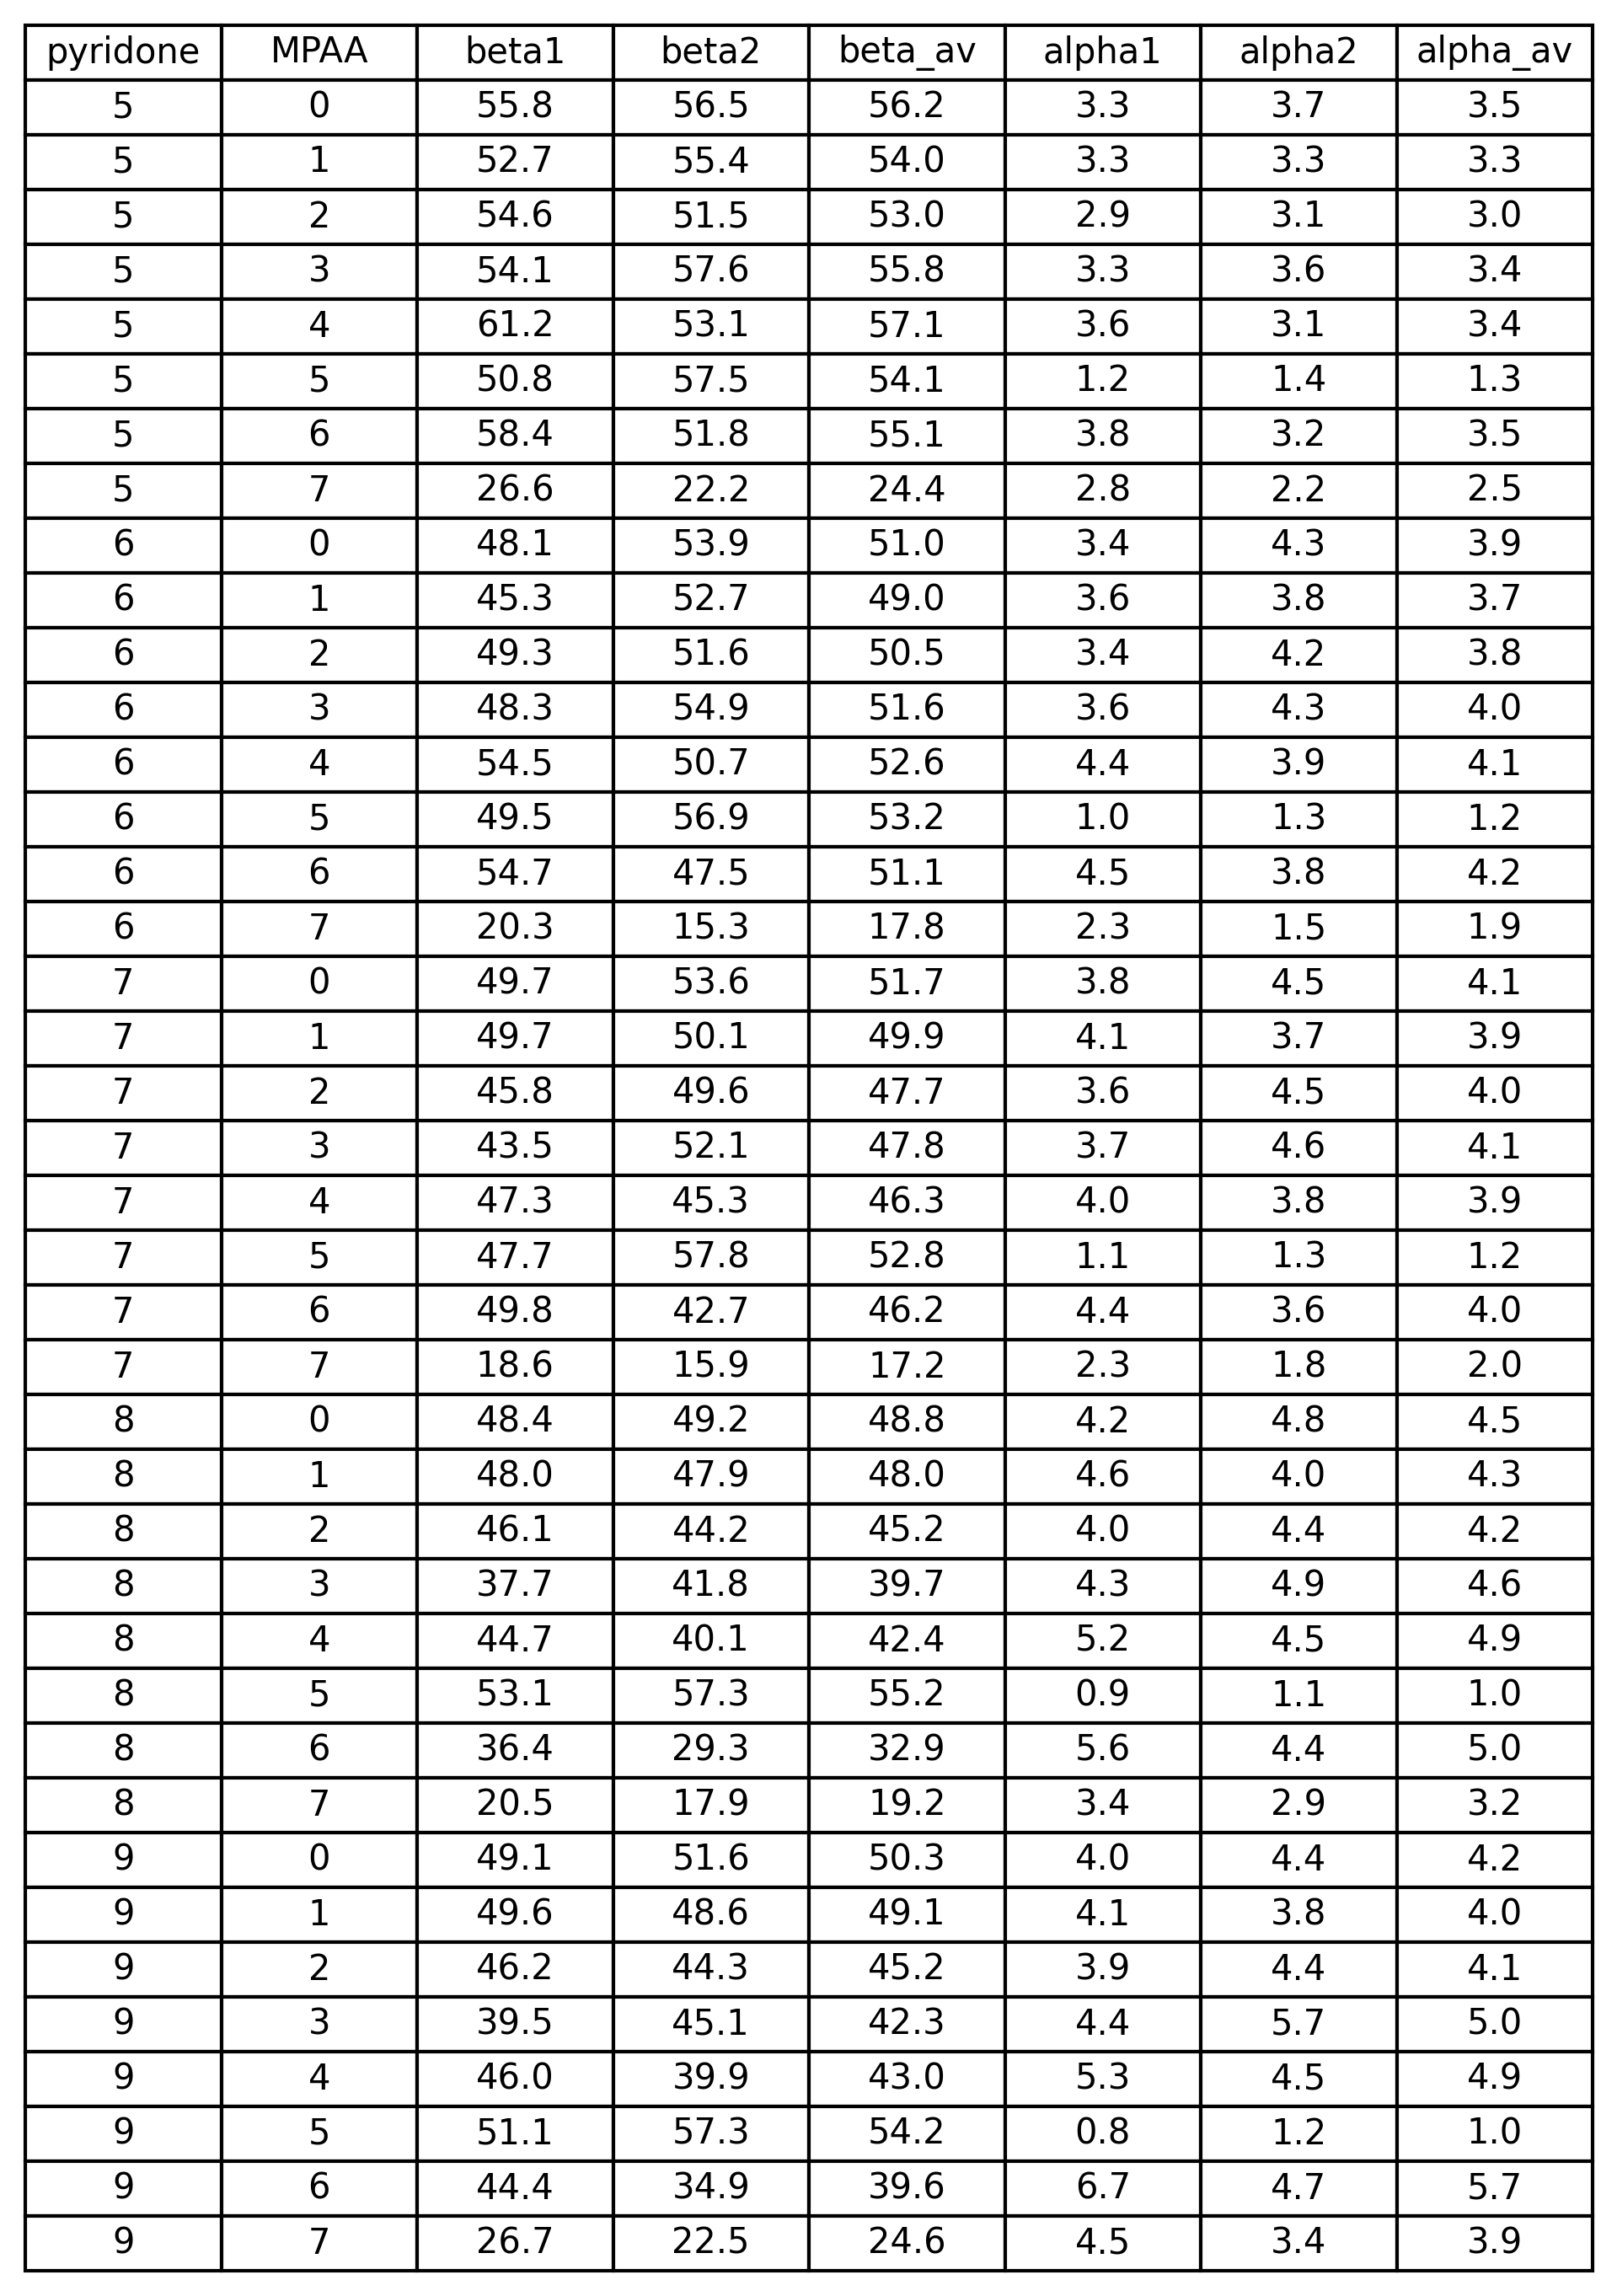

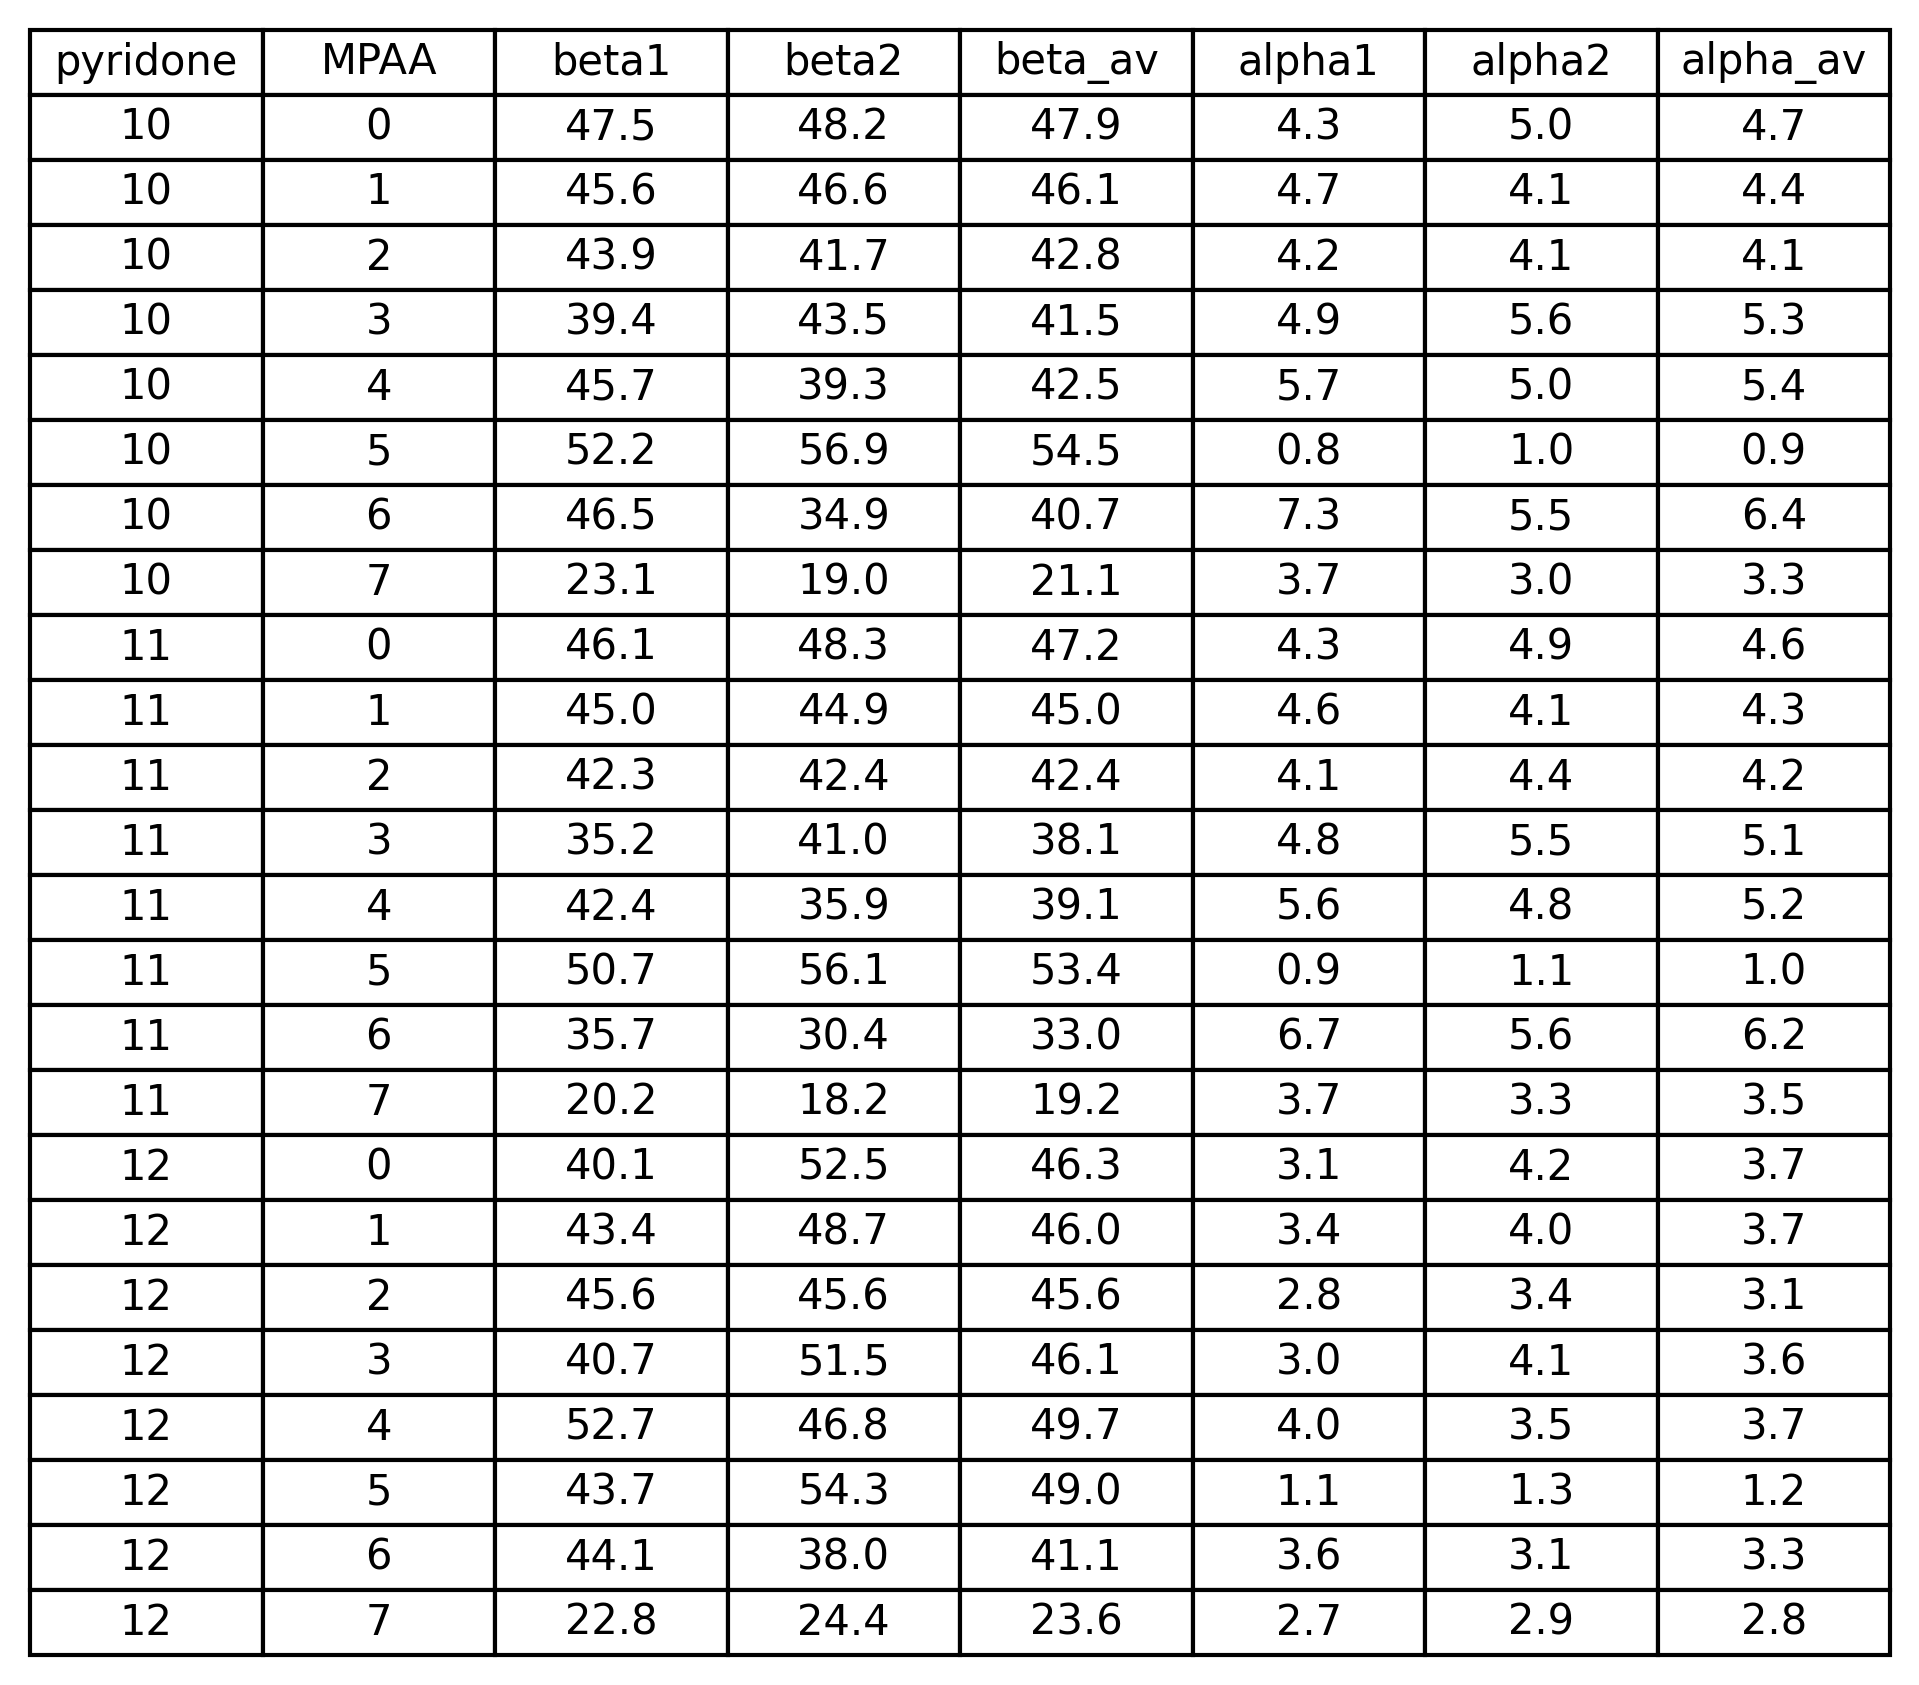

In [9]:
import matplotlib.pyplot as plt

for key, value in separation.items():
    fig, ax = plt.subplots(figsize=(8, 1), dpi=300)
    
    table = ax.table(
        cellText=df.filter(pl.col("pyridone").is_in(value)).to_numpy(),
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )
    table.scale(1.0, 1.3)
    
    ax.axis("off")
    
    plt.savefig(
        f"{file}_table{key}.png",
        transparent=True,
        bbox_inches="tight",
        pad_inches=0.1
    )
    plt.show()